# BirdSet layer-fusion weights — XC + NASA soundscapes vs external baselines

The weights the **layerwise** probe (`ViTProtoLayerwise`) learns over the 12
encoder blocks: one softmax-normalised weight per block, so a high weight means
that block's features were more useful to the prototype head. W&B logs them
post-softmax (they sum to 1 per run) plus a `centroid` summary — the weighted mean
block index, so a high centroid means the probe leans on late blocks.

This is the readout that used to be §4 and the tail of §9 of
`birdset_results_nasa.ipynb`; the benchmark numbers for the same runs stay there.
Only the layerwise head has these weights at all — a linear or final-layer probe
reads one fixed block by construction.

Three readouts:

1. **ours vs the external encoders** — does an AudioSet/XC MAE keep its useful
   features at a different depth than ours?
2. **400k vs 1M steps, both mixes** — does a longer schedule move them? (the 2×2
   of `birdset_results_nasa.ipynb` §3)
3. **NASA windowing, events vs regions** — did the `v2` store change *where* the
   useful features sit? (§9 there)

plus the centroid table, which summarises all of them in one number per cell.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import wandb

In [2]:
# --- Pull the layerwise probing runs from W&B ---
# Only what the layer weights need: the *layerwise* probes of the fixed backbones.
# Everything except the dataset is resolved from the logged CONFIG rather than the
# run name, because the config is ground truth and survives renaming:
#   dataset  -> first token of the run name (the one thing only the name carries)
#   backbone -> `trainer.resume_from_checkpoint`, matched as a FULL repo-relative
#               PATH. Basename matching would be wrong here: `step_0400000.ckpt`
#               names the annealed 400k-schedule run AND two step-sweep
#               checkpoints of the 1M runs. Step-sweep checkpoints are simply not
#               in the map, which is what keeps them out of this notebook.
#   head     -> (`module.model._target_`, `module.freeze_backbone`); only the
#               layerwise pair is kept. `ViTProtoFloat` is not enough on its own
#               to identify a head — it is both final-layer probing and, unfrozen,
#               full finetuning — but neither logs layer weights anyway.
#   seed     -> the logged `seed`. Every seed is kept and the weights are averaged
#               over them: the two 1M cells have seeds 1 and 2, the rest seed 1.
ENTITY = "mwirth"
PROJECT = "soundscape_ssl"

XC_400K = "XC (400k)"                    # cold start, 400k from scratch
XC_400K_WARM = "XC (400k, warm)"         # the superseded warm restart
XC_1M = "XC (1M)"
XC_NASA_400K = "XC + NASA (400k)"        # NASA = fixed 5 s events store
XC_NASA_400K_V2 = "XC + NASA v2 (400k)"  # NASA = region store + random crop
XC_NASA_1M = "XC + NASA (1M)"
AUDIOMAE = "AudioMAE (AS-2M)"
BIRDMAE = "Bird-MAE-Base"

REPO = "/home/moritz_earthspecies_org/soundscape_mae/"

# Full repo-relative checkpoint path -> backbone. Same map as
# `birdset_results_nasa.ipynb`; see its header for what each encoder is.
CKPT_TO_BACKBONE = {
    "checkpoints/XC_400k_cold.ckpt": XC_400K,             # cold, from scratch
    "outputs/2026-07-01/09-53-05/checkpoints/step_0400000.ckpt": XC_400K_WARM,
    "checkpoints/XC_long.ckpt": XC_400K_WARM,             # same encoder, copied
    "checkpoints/XC_1M.ckpt": XC_1M,
    "checkpoints/XC_nasa_400k.ckpt": XC_NASA_400K,        # fixed 5 s event store
    "checkpoints/XC_nasa_400k_v2.ckpt": XC_NASA_400K_V2,  # region store, random crop
    "checkpoints/XC_nasa_1M.ckpt": XC_NASA_1M,
    "checkpoints/audiomae.ckpt": AUDIOMAE,      # scripts/convert_external_ckpt.py
    "checkpoints/birdmae_base.ckpt": BIRDMAE,
}

LAYERWISE_TARGET = "soundscape_ssl.models.ViTProtoLayerwise"

VAL_DATASETS = ["POW"]          # validation set -> excluded from the means
TEST_DATASETS = ["HSN", "NBP", "NES", "PER", "SNE", "SSW", "UHH"]
DATASETS = VAL_DATASETS + TEST_DATASETS

api = wandb.Api()

rows = []
for run in api.runs(f"{ENTITY}/{PROJECT}"):
    parts = (run.name or "").split("-")
    if len(parts) < 4 or parts[1] != "test_5s" or parts[0] not in DATASETS:
        continue
    cfg = run.config
    module = cfg.get("module", {}) or {}
    ckpt = (cfg.get("trainer", {}) or {}).get("resume_from_checkpoint") or ""
    backbone = CKPT_TO_BACKBONE.get(ckpt.replace(REPO, ""))
    layerwise = ((module.get("model", {}) or {}).get("_target_") == LAYERWISE_TARGET
                 and bool(module.get("freeze_backbone", True)))
    if backbone is None or not layerwise or cfg.get("seed") is None:
        continue
    rows.append({"dataset": parts[0], "backbone": backbone, "seed": cfg["seed"],
                 "state": run.state, "run_id": run.id,
                 "created": pd.to_datetime(run.created_at, utc=True)})

raw_df = pd.DataFrame(rows)

# One run per (dataset, backbone, seed): prefer the most recent *finished* run,
# else the most recent of any state. This de-duplicates repeated evaluation
# batches; the seed is part of the key, so a genuine second seed is a new row.
runs_df = (raw_df.assign(_finished=(raw_df["state"] == "finished").astype(int))
                 .sort_values(["_finished", "created"])
                 .drop_duplicates(["dataset", "backbone", "seed"], keep="last")
                 .drop(columns="_finished"))

# One row per (dataset, backbone), carrying the seed run ids whose weights get
# averaged. Cells whose runs logged no weights simply drop out further down.
layerwise_df = (runs_df.groupby(["dataset", "backbone"], as_index=False)
                       .agg(seeds=("seed", lambda s: sorted(s)),
                            run_ids=("run_id", list))
                       .sort_values(["backbone", "dataset"])
                       .reset_index(drop=True))

print(f"{len(raw_df)} layerwise runs -> {len(runs_df)} deduped -> "
      f"{len(layerwise_df)} (dataset, backbone) cells\n")
print("seeds per cell:")
print(runs_df.pivot_table(index="dataset", columns="backbone", values="seed",
                          aggfunc="count")
             .reindex(index=DATASETS).fillna(0).astype(int).to_string())
unfinished = runs_df.loc[runs_df["state"] != "finished",
                         ["dataset", "backbone", "seed", "state"]]
if len(unfinished):
    print("\nWARNING — runs kept that are not finished:")
    print(unfinished.to_string(index=False))


wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /home/moritz_earthspecies_org/.netrc.


81 layerwise runs -> 80 deduped -> 64 (dataset, backbone) cells

seeds per cell:
backbone  AudioMAE (AS-2M)  Bird-MAE-Base  XC (1M)  XC (400k)  XC (400k, warm)  XC + NASA (1M)  XC + NASA (400k)  XC + NASA v2 (400k)
dataset                                                                                                                              
POW                      1              1        2          1                1               2                 1                    1
HSN                      1              1        2          1                1               2                 1                    1
NBP                      1              1        2          1                1               2                 1                    1
NES                      1              1        2          1                1               2                 1                    1
PER                      1              1        2          1                1               2                 1   

In [3]:
# --- Series and colors ---
# Same palette as `birdset_results_nasa.ipynb` so the two can be read against each
# other: externals keep their hues, ours use hue = data mix and dark shade = the
# 1M schedule.
BASELINES = [AUDIOMAE, BIRDMAE, XC_400K, XC_NASA_400K]
ABLATION = [XC_400K, XC_1M, XC_NASA_400K, XC_NASA_1M]      # the 2x2, mix-major
WINDOWING = [XC_400K, XC_NASA_400K, XC_NASA_400K_V2]       # events vs regions

COLORS = {
    AUDIOMAE: "#ff7f0e",
    BIRDMAE: "#2ca02c",
    XC_400K: "#9467bd",
    XC_1M: "#54278f",
    XC_400K_WARM: "#bcbddc",
    XC_NASA_400K: "#5BC5DB",
    XC_NASA_400K_V2: "#e377c2",
    XC_NASA_1M: "#1b7f9e",
}


In [4]:
# --- Fetch & plot the learned per-block weights for layerwise runs ---
def _fetch_layer_weights(run_ids):
    """{block_no (1-indexed): post-softmax weight} for one (dataset, backbone)
    cell, averaged over its seeds. Runs that logged no weights are skipped."""
    per_seed = []
    for run_id in run_ids:
        s = api.run(f"{ENTITY}/{PROJECT}/{run_id}").summary
        w = {int(k.rsplit("_", 1)[1]): s[k]
             for k in s.keys() if k.startswith("layer_weights/block_")}
        if w:
            per_seed.append(w)
    if not per_seed:
        return {}
    blocks = set.intersection(*[set(w) for w in per_seed])
    return {b: float(np.mean([w[b] for w in per_seed])) for b in blocks}


def layer_weights_df(backbones):
    """Tidy (backbone, dataset, block, weight) frame for the given backbones,
    one row per block with the weight averaged over the cell's seeds."""
    rows = []
    for _, r in layerwise_df[layerwise_df["backbone"].isin(backbones)].iterrows():
        for block, w in _fetch_layer_weights(r["run_ids"]).items():
            rows.append({"backbone": r["backbone"], "dataset": r["dataset"],
                         "block": block, "weight": w})
    return pd.DataFrame(rows)


def plot_layer_weights(backbones):
    """Per-dataset heatmap per backbone + mean profile over the datasets that all
    the given backbones share. Runs with no logged weights simply don't appear."""
    lw = layer_weights_df(backbones)
    nblocks = int(lw["block"].max())
    blocks = np.arange(1, nblocks + 1)
    print(f"{nblocks} blocks; datasets with weights per backbone: "
          f"{lw.groupby('backbone')['dataset'].nunique().to_dict()}")
    common = sorted(set.intersection(*[set(lw.loc[lw.backbone == b, "dataset"])
                                       for b in backbones]), key=DATASETS.index)

    fig, axes = plt.subplots(1, len(backbones) + 1,
                            figsize=(5.5 * len(backbones) + 5.5, 4.8))
    vmax = lw["weight"].max()
    for ax, backbone in zip(axes, backbones):
        sub = lw[lw.backbone == backbone]
        order = [d for d in DATASETS if d in set(sub.dataset)]
        mat = (sub.pivot_table(index="dataset", columns="block", values="weight")
                  .reindex(index=order, columns=blocks))
        im = ax.imshow(mat.values, aspect="auto", cmap="viridis", vmin=0, vmax=vmax)
        ax.set_xticks(range(nblocks)); ax.set_xticklabels(blocks)
        ax.set_yticks(range(len(order))); ax.set_yticklabels(order)
        ax.set_xlabel("encoder block")
        ax.set_title(f"{backbone}\nlayer weights (softmax)")
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    axm = axes[-1]
    for backbone in backbones:
        prof = (lw[(lw.backbone == backbone) & (lw.dataset.isin(common))]
                .groupby("block")["weight"].mean().reindex(blocks))
        axm.plot(blocks, prof.values, marker="o", color=COLORS[backbone], label=backbone)
    axm.set_xlabel("encoder block"); axm.set_ylabel("mean weight (softmax)")
    axm.set_title(f"mean over shared datasets\n({', '.join(common)})")
    axm.set_xticks(blocks); axm.grid(alpha=0.3); axm.legend(fontsize=8)
    fig.tight_layout(); plt.show()
    return lw


def _centroid(run_ids):
    vals = [api.run(f"{ENTITY}/{PROJECT}/{run_id}").summary.get("layer_weights/centroid")
            for run_id in run_ids]
    vals = [v for v in vals if v is not None]
    return float(np.mean(vals)) if vals else np.nan


## 1. Ours vs the external encoders

All layerwise, all 400k on our side.

12 blocks; datasets with weights per backbone: {'AudioMAE (AS-2M)': 8, 'Bird-MAE-Base': 8, 'XC (400k)': 8, 'XC + NASA (400k)': 8}


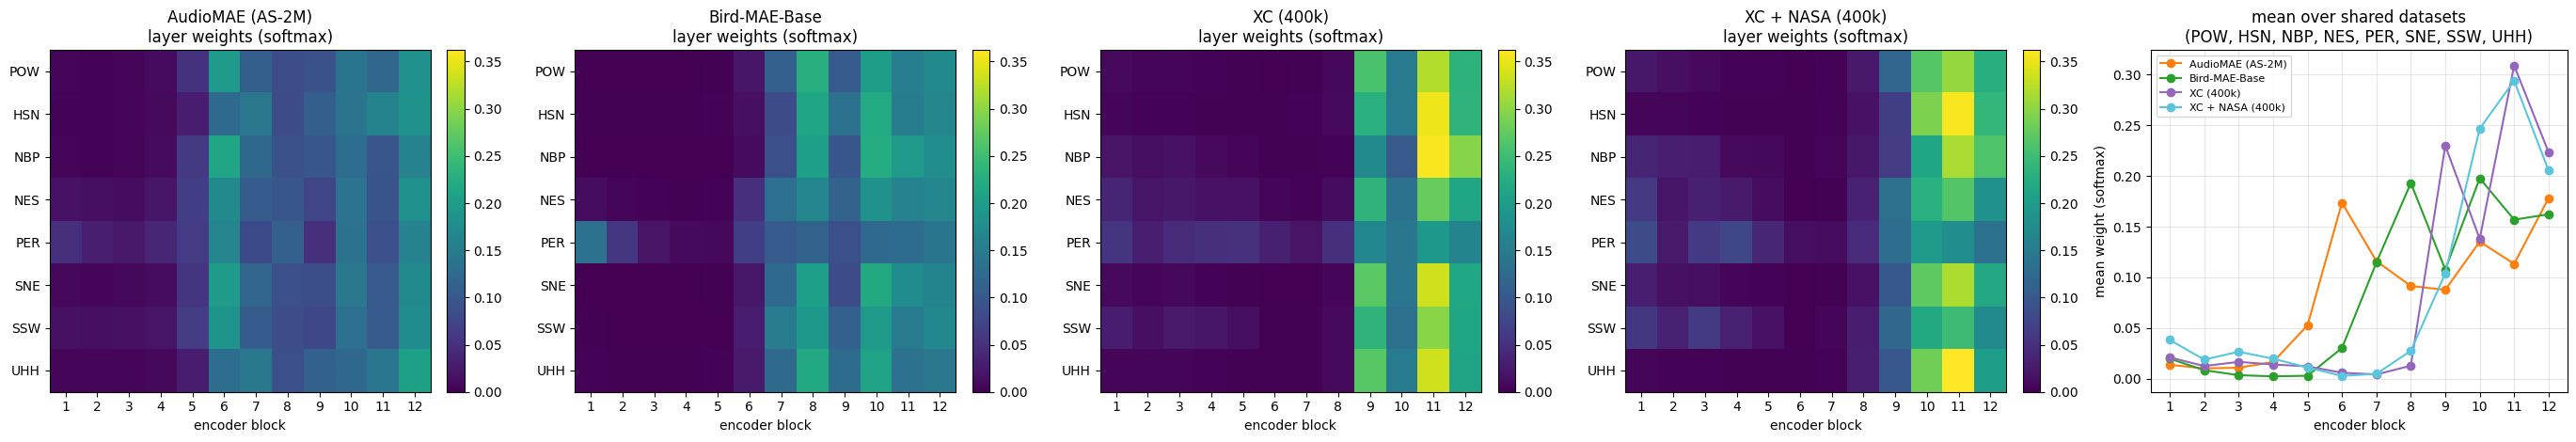

In [5]:
# Ours vs the external encoders (all layerwise, all 400k for ours)
lw_external = plot_layer_weights([AUDIOMAE, BIRDMAE, XC_400K, XC_NASA_400K])

## 2. Training length — 400k vs 1M, both mixes

The 2×2 of `birdset_results_nasa.ipynb` §3, read as depth profiles.

12 blocks; datasets with weights per backbone: {'XC (1M)': 8, 'XC (400k)': 8, 'XC + NASA (1M)': 8, 'XC + NASA (400k)': 8}


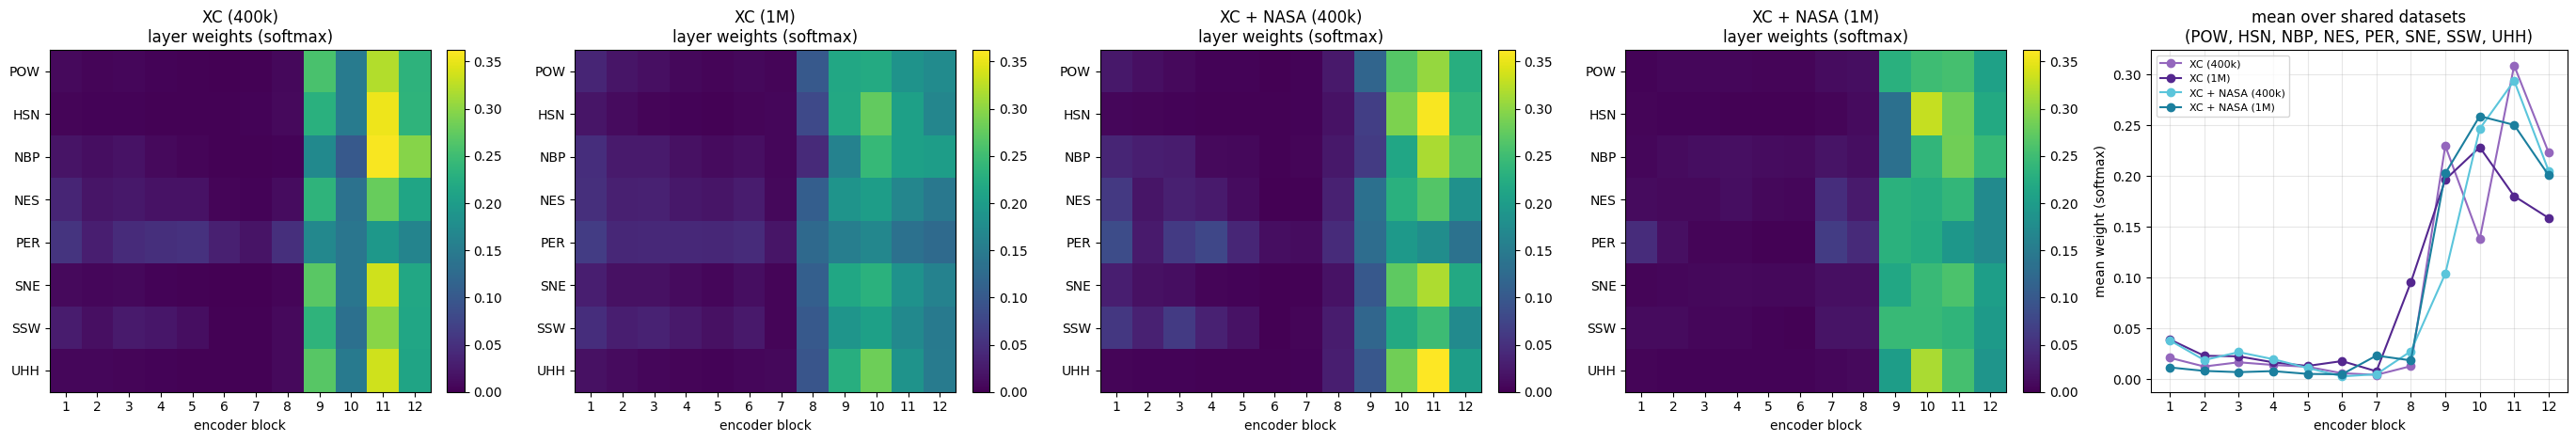

In [6]:
# Training-length effect at fixed data mix, for both mixes: the `birdset_results_nasa.ipynb` §3 2x2
lw_ablation = plot_layer_weights(ABLATION)


## 3. NASA windowing — fixed 5 s events vs detection regions (`v2`)

The three arms of `birdset_results_nasa.ipynb` §9.

12 blocks; datasets with weights per backbone: {'XC (400k)': 8, 'XC + NASA (400k)': 8, 'XC + NASA v2 (400k)': 8}


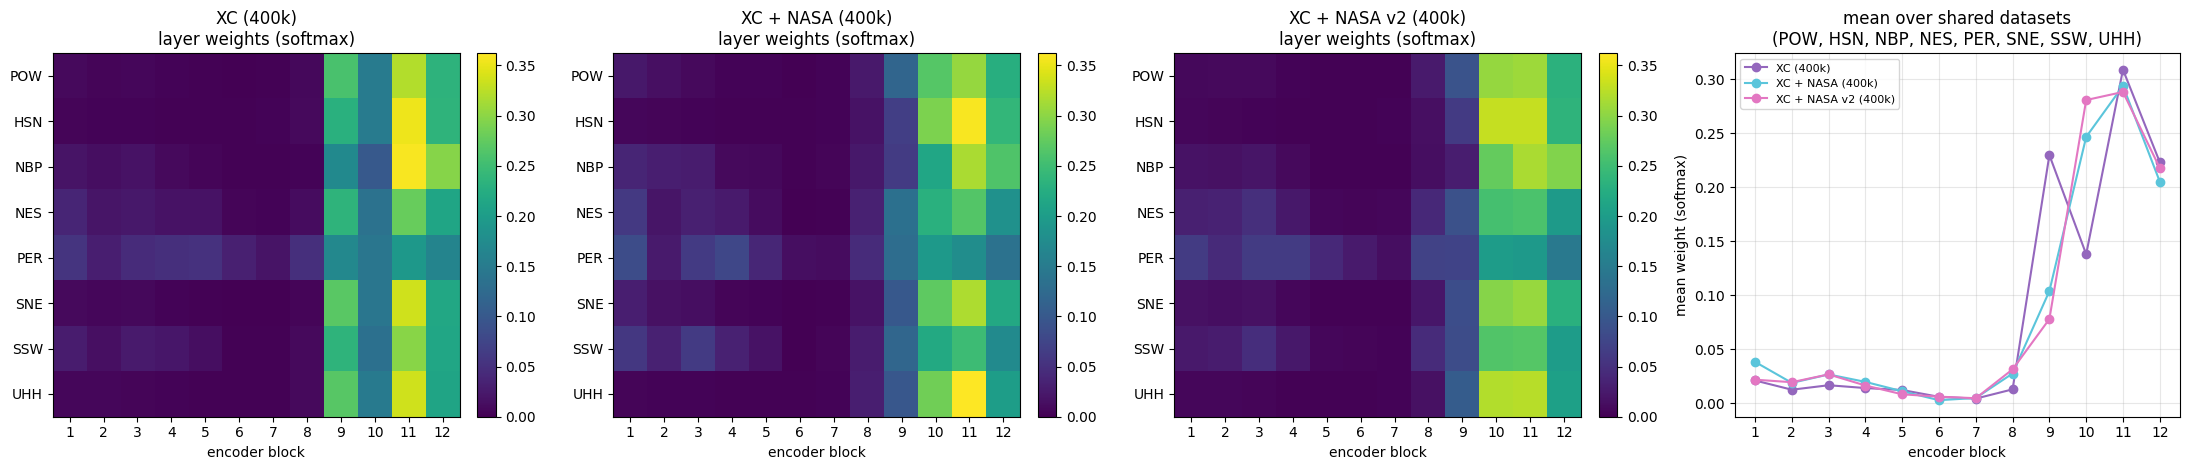

layer-weight centroid (1 = first block, 12 = last)
backbone  XC (400k)  XC + NASA (400k)  XC + NASA v2 (400k)
dataset                                                   
POW           10.32             10.14                10.39
HSN           10.43             10.58                10.54
NBP           10.27              9.83                10.33
NES            9.55              9.28                 9.37
PER            8.47              8.08                 8.19
SNE           10.27             10.06                10.21
SSW            9.70              8.88                 9.50
UHH           10.28             10.46                10.41

test-set mean (POW excluded):
backbone
XC (400k)              9.85
XC + NASA (400k)       9.60
XC + NASA v2 (400k)    9.79


In [7]:
# Did the windowing change *where* the useful features sit? Same readout as the
# sections above, restricted to these three arms.
win_weights = plot_layer_weights(WINDOWING)

win_centroids = pd.DataFrame([
    {"backbone": r["backbone"], "dataset": r["dataset"],
     "centroid": _centroid(r["run_ids"])}
    for _, r in layerwise_df[layerwise_df["backbone"].isin(WINDOWING)].iterrows()
]).pivot_table(index="dataset", columns="backbone", values="centroid").reindex(
    index=DATASETS, columns=WINDOWING)

print("layer-weight centroid (1 = first block, 12 = last)")
print(win_centroids.round(2).to_string())
print("\ntest-set mean (POW excluded):")
print(win_centroids.loc[TEST_DATASETS].mean().round(2).to_string())


## 4. Centroids

The one-number summary of every profile above. Careful: the centroid is a mean over the whole profile, so it conflates "peaked late" with "spread out" — for a bimodal profile the heatmaps above are the readout.

In [8]:
# Weighted mean block index per cell (averaged over seeds where there are two):
# high = the probe leans on late blocks.
centroids = pd.DataFrame([
    {"backbone": r["backbone"], "dataset": r["dataset"],
     "centroid": _centroid(r["run_ids"])}
    for _, r in layerwise_df.iterrows()
]).pivot_table(index="dataset", columns="backbone", values="centroid").reindex(
    index=DATASETS, columns=BASELINES + [XC_1M, XC_NASA_1M])

print("layer-weight centroid (1 = first block, 12 = last)")
print(centroids.round(2).to_string())
print("\ntest-set mean (POW excluded):")
print(centroids.loc[TEST_DATASETS].mean().round(2).to_string())

layer-weight centroid (1 = first block, 12 = last)
backbone  AudioMAE (AS-2M)  Bird-MAE-Base  XC (400k)  XC + NASA (400k)  XC (1M)  XC + NASA (1M)
dataset                                                                                        
POW                   8.68           9.49      10.32             10.14     9.39           10.17
HSN                   9.02           9.54      10.43             10.58     9.78           10.43
NBP                   8.42           9.71      10.27              9.83     9.32           10.12
NES                   8.35           9.25       9.55              9.28     8.75            9.78
PER                   7.81           7.58       8.47              8.08     8.10            9.42
SNE                   8.50           9.52      10.27             10.06     9.40           10.09
SSW                   8.33           9.41       9.70              8.88     8.82           10.00
UHH                   8.98           9.28      10.28             10.46     9.69      